# YOLCULUK Kapsamlı Analiz — Multi-Aggregate Üretimi

**Kaynak:** `YOLCULUK/DATA/yolculuk_temiz_final.csv` (4.4 GB, 5.135.399 satır)

**Tarih:** 2025-01-01 → 2025-06-30 (6 ay)

**Çıktılar (5 ayrı JSON, iett_panel'in farklı sekmelerini besler):**

| Çıktı | Hedef Sekme | İçerik |
|---|---|---|
| `yolcu_agg.json` | 👥 Yolcu | KPI + top hatlar/duraklar/ilçe + saat/ay dağılım |
| `bilet_agg.json` | 🎫 Bilet | Bilet tipi/kategori detay × yakıt/araç/operatör/saat |
| `filo_yolcu_agg.json` | 🚌 Filo | Araç bazlı yolcu profili (KAPINO × yolculuk) |
| `operator_garaj_agg.json` | 🏭 Garaj | Operatör/garaj bazlı yolcu hacmi |
| `aktarma_pattern.json` | 🔍 Hat Analizi | Aktarma örüntüleri (ONCEKI_HAT → GUNCEL_HAT chain) |

**Strateji:** TEK chunk pass'te tüm aggregator'ları besle (4.4 GB CSV'yi 2 kez okumamak için).

## 21 Analiz Bölümü
1. Genel KPI (toplam yolculuk, hat/durak/aktarma)
2. Top 30 hat × yolculuk
3. Top 30 durak × yolculuk
4. İlçe/mahalle bazlı yolcu dağılımı
5. Saatlik dağılım (0-23)
6. Günlük/aylık trend
7. Hafta içi vs hafta sonu profili (saat × WD/WE matrisi)
8. Bilet tipi dağılımı (İndirimli/Tam/Ücretsiz)
9. Bilet kategorisi (Öğrenci/Tam/Yaşlı/65+/Özürlü)
10. Geçiş türü (Kontürlü/Aylık)
11. Aktarma tipi dağılımı
12. Ulaşım türü (Otobüs/Metrobüs)
13. Operatör bazlı yolculuk
14. Garaj bazlı yolculuk
15. Marka × yolcu hacmi
16. Araç cinsi (Koruklu/Solo)
17. Emisyon standardı dağılımı
18. Yakıt türü × yolculuk
19. Araç bazlı (KAPINO) yolculuk (top 50)
20. Aktarma örüntüleri (chain: ONCEKI → GUNCEL)
21. Hat × Saat ısı haritası (top 20 hat × 24 saat)

---
## 1. İmportlar ve Yollar

In [1]:
import pandas as pd
import json
import os
import time
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Yollar
CSV_PATH = 'DATA/yolculuk_temiz_final.csv'
OUT_DIR = '../panel_data'
os.makedirs(OUT_DIR, exist_ok=True)

# Tüm aggregator'lar için gerekli kolonlar
USECOLS = [
    'GECISZAMANI', 'DAKTARMATIPI', 'DBILETTIPI', 'DBILETKATEGORI', 'DGECISTURU', 'DMEDYATIPI',
    'GUN', 'AY', 'HAFTA', 'HAFTASONU',
    'GUNCEL_HATKODU', 'GUNCEL_HATADI', 'GUNCEL_HATILCE', 'GUNCEL_HATGARAJI', 'GUNCEL_HATCINSI',
    'ONCEKI_HATKODU', 'ONCEKI_HATADI',
    'ULASIMTURU_TANIM', 'DURAKKODU', 'DURAKADI', 'ILCE', 'MAHALLE',
    'GUNCEL_USTOPERATOR', 'OPERATORADI', 'GARAJ', 'KAPINO',
    'MARKA', 'ARACCINSI', 'EMISYON', 'YAKITTURU', 'KAPASITE', 'ENGELLI'
]

CHUNK_SIZE = 500_000

print(f'CSV: {CSV_PATH}')
print(f'Boyut: {os.path.getsize(CSV_PATH)/(1024**3):.1f} GB')
print(f'Kolon sayısı: {len(USECOLS)}')
print(f'Hedef çıktı klasörü: {os.path.abspath(OUT_DIR)}')
print(f'Chunk: {CHUNK_SIZE:,}, tahmini süre: 90-120 sn')

CSV: DATA/yolculuk_temiz_final.csv
Boyut: 4.1 GB
Kolon sayısı: 32
Hedef çıktı klasörü: c:\Users\asus\Desktop\Datathon\panel_data
Chunk: 500,000, tahmini süre: 90-120 sn


---
## 2. Aggregator'ları Tanımla

Her sekme için ayrı Counter/dict. Tek pass'te hepsi beslenir.

In [2]:
# === GLOBAL SAYAÇLAR ===
toplam = 0
toplam_aktarmasiz = 0

# === YOLCU SEKMESİ (yolcu_agg.json) ===
hat = Counter(); hat_adi = {}
durak = Counter(); durak_adi = {}
ilce = Counter(); mahalle = Counter()
saat = Counter(); gun = Counter(); ay = Counter()
haftaici_saat = Counter(); haftasonu_saat = Counter()  # Hafta içi/sonu profili
ulasim_tur = Counter()

# === BİLET SEKMESİ (bilet_agg.json) ===
bilet_tip = Counter()
bilet_kategori = Counter()
bilet_medya = Counter()
gecis_turu = Counter()
aktarma_tip = Counter()
# Cross matris: bilet kategorisi × saat
bilet_saat = defaultdict(Counter)
# Cross matris: bilet × ay
bilet_ay = defaultdict(Counter)
# Cross matris: bilet × yakıt
bilet_yakit = defaultdict(Counter)
# Cross matris: bilet × ulaşım türü
bilet_ulasim = defaultdict(Counter)

# === FİLO SEKMESİ (filo_yolcu_agg.json) ===
kapino_yolcu = Counter()  # Araç bazlı yolculuk
marka = Counter()
arac_cinsi = Counter()  # Koruklu/Solo
emisyon = Counter()
yakit = Counter()
engelli = Counter()
# Kapasite × yolculuk
kapasite_bandi = Counter()  # <50, 50-80, 80-100, 100-150, 150+

# === GARAJ/OPERATÖR (operator_garaj_agg.json) ===
operator_ust = Counter()
operator = Counter()
garaj_yolcu = Counter()
garaj_hat_set = defaultdict(set)  # garaj başına unique hat

# === AKTARMA ÖRÜNTÜSÜ (aktarma_pattern.json) ===
aktarma_chain = Counter()  # (oncekihat, guncelhat) tuple
aktarma_oncekihat = Counter()  # önceki hat dağılımı

# === HAT × SAAT ISI HARİTASI ===
hat_saat_matris = defaultdict(Counter)  # hat → {saat → sayı}

print('Aggregator yapıları hazır')
print(f'  Yolcu sekmesi:    {sum([1 for _ in [hat, durak, ilce, saat]])} ana counter')
print(f'  Bilet sekmesi:    cross matrix dahil')
print(f'  Filo sekmesi:     KAPINO bazlı + kapasite bandı')
print(f'  Garaj sekmesi:    operatör + garaj + hat çeşitliliği')
print(f'  Aktarma örüntü:   chain (önceki→güncel)')

Aggregator yapıları hazır
  Yolcu sekmesi:    4 ana counter
  Bilet sekmesi:    cross matrix dahil
  Filo sekmesi:     KAPINO bazlı + kapasite bandı
  Garaj sekmesi:    operatör + garaj + hat çeşitliliği
  Aktarma örüntü:   chain (önceki→güncel)


---
## 3. Chunk-by-Chunk Aggregate (TEK PASS)

5.1M satır × 32 kolon. 500K chunk × 11 = 11 chunk. ~90 saniye.

In [3]:
def kapasite_band_func(k):
    if pd.isna(k): return 'BILINMIYOR'
    k = float(k)
    if k < 50: return '<50'
    if k < 80: return '50-80'
    if k < 100: return '80-100'
    if k < 150: return '100-150'
    return '150+'

t0 = time.time()
chunks_done = 0

for chunk in pd.read_csv(CSV_PATH, usecols=USECOLS, chunksize=CHUNK_SIZE, low_memory=False):
    toplam += len(chunk)
    sade = chunk[chunk['DAKTARMATIPI'] != 'Aktarma']
    toplam_aktarmasiz += len(sade)
    
    # === YOLCU SEKMESİ ===
    hat.update(chunk['GUNCEL_HATKODU'].dropna())
    for k, a in chunk[['GUNCEL_HATKODU', 'GUNCEL_HATADI']].dropna().drop_duplicates().values:
        if k not in hat_adi: hat_adi[k] = str(a)
    durak.update(chunk['DURAKKODU'].dropna())
    for k, a in chunk[['DURAKKODU', 'DURAKADI']].dropna().drop_duplicates().values:
        if k not in durak_adi: durak_adi[k] = str(a)
    ilce.update(chunk['GUNCEL_HATILCE'].dropna())
    mahalle.update(chunk['MAHALLE'].dropna())
    
    # Saat parse (zaman aldığı için bir kez)
    saatler = pd.to_datetime(chunk['GECISZAMANI'], errors='coerce').dt.hour
    saatler_clean = saatler.dropna().astype(int)
    saat.update(saatler_clean)
    gun.update(chunk['GUN'].dropna().astype(int))
    ay.update(chunk['AY'].dropna().astype(int))
    
    # Hafta içi vs hafta sonu × saat (cross)
    chunk_sa = chunk.copy()
    chunk_sa['_saat'] = saatler
    wd_mask = chunk_sa['HAFTASONU'] != 1
    haftaici_saat.update(chunk_sa.loc[wd_mask, '_saat'].dropna().astype(int))
    haftasonu_saat.update(chunk_sa.loc[~wd_mask, '_saat'].dropna().astype(int))
    
    ulasim_tur.update(chunk['ULASIMTURU_TANIM'].dropna())
    
    # === BİLET SEKMESİ ===
    bilet_tip.update(chunk['DBILETTIPI'].dropna())
    bilet_kategori.update(chunk['DBILETKATEGORI'].dropna())
    bilet_medya.update(chunk['DMEDYATIPI'].dropna())
    gecis_turu.update(chunk['DGECISTURU'].dropna())
    aktarma_tip.update(chunk['DAKTARMATIPI'].dropna())
    
    # Cross: bilet × saat
    df_cross = chunk[['DBILETKATEGORI', 'DBILETTIPI', 'AY', 'YAKITTURU', 'ULASIMTURU_TANIM']].copy()
    df_cross['_saat'] = saatler
    df_cross = df_cross.dropna(subset=['DBILETKATEGORI', '_saat'])
    df_cross['_saat'] = df_cross['_saat'].astype(int)
    
    for (kat, s), n in df_cross.groupby(['DBILETKATEGORI', '_saat']).size().items():
        bilet_saat[str(kat)][int(s)] += int(n)
    for (kat, m), n in df_cross.dropna(subset=['AY']).groupby(['DBILETKATEGORI', 'AY']).size().items():
        bilet_ay[str(kat)][int(m)] += int(n)
    for (kat, y), n in df_cross.dropna(subset=['YAKITTURU']).groupby(['DBILETKATEGORI', 'YAKITTURU']).size().items():
        bilet_yakit[str(kat)][str(y)] += int(n)
    for (kat, u), n in df_cross.dropna(subset=['ULASIMTURU_TANIM']).groupby(['DBILETKATEGORI', 'ULASIMTURU_TANIM']).size().items():
        bilet_ulasim[str(kat)][str(u)] += int(n)
    
    # === FİLO SEKMESİ ===
    kapino_yolcu.update(chunk['KAPINO'].dropna())
    marka.update(chunk['MARKA'].dropna())
    arac_cinsi.update(chunk['ARACCINSI'].dropna())
    emisyon.update(chunk['EMISYON'].dropna())
    yakit.update(chunk['YAKITTURU'].dropna())
    engelli.update(chunk['ENGELLI'].dropna())
    
    kapasite_bands = chunk['KAPASITE'].apply(kapasite_band_func)
    kapasite_bandi.update(kapasite_bands)
    
    # === GARAJ/OPERATÖR ===
    operator_ust.update(chunk['GUNCEL_USTOPERATOR'].dropna())
    operator.update(chunk['OPERATORADI'].dropna())
    garaj_yolcu.update(chunk['GUNCEL_HATGARAJI'].dropna())
    
    # Garaj başına unique hat
    for g, h in chunk[['GUNCEL_HATGARAJI', 'GUNCEL_HATKODU']].dropna().drop_duplicates().values:
        garaj_hat_set[str(g)].add(str(h))
    
    # === AKTARMA ÖRÜNTÜSÜ ===
    akt = chunk[chunk['DAKTARMATIPI'] == 'Aktarma'][['ONCEKI_HATKODU', 'GUNCEL_HATKODU']].dropna()
    aktarma_oncekihat.update(akt['ONCEKI_HATKODU'])
    for o, g in akt.values:
        aktarma_chain[(str(o), str(g))] += 1
    
    # === HAT × SAAT ISI HARİTASI ===
    df_hs = chunk[['GUNCEL_HATKODU']].copy()
    df_hs['_saat'] = saatler
    df_hs = df_hs.dropna()
    df_hs['_saat'] = df_hs['_saat'].astype(int)
    for (h, s), n in df_hs.groupby(['GUNCEL_HATKODU', '_saat']).size().items():
        hat_saat_matris[str(h)][int(s)] += int(n)
    
    chunks_done += 1
    elapsed = time.time() - t0
    print(f'Chunk {chunks_done}: {toplam:,} toplam · {toplam_aktarmasiz:,} aktarmasiz · {elapsed:.0f}s')

print(f'\n✓ {chunks_done} chunk, {time.time()-t0:.0f} sn')
print(f'  Toplam: {toplam:,}')
print(f'  Aktarma hariç: {toplam_aktarmasiz:,}')
print(f'  Unique araç (KAPINO): {len(kapino_yolcu):,}')
print(f'  Aktarma chain çeşitliliği: {len(aktarma_chain):,}')

Chunk 1: 500,000 toplam · 470,837 aktarmasiz · 9s
Chunk 2: 1,000,000 toplam · 940,978 aktarmasiz · 17s
Chunk 3: 1,500,000 toplam · 1,412,136 aktarmasiz · 26s
Chunk 4: 2,000,000 toplam · 1,884,423 aktarmasiz · 34s
Chunk 5: 2,500,000 toplam · 2,354,510 aktarmasiz · 43s
Chunk 6: 3,000,000 toplam · 2,823,010 aktarmasiz · 51s
Chunk 7: 3,500,000 toplam · 3,295,825 aktarmasiz · 60s
Chunk 8: 4,000,000 toplam · 3,765,803 aktarmasiz · 68s
Chunk 9: 4,500,000 toplam · 4,236,537 aktarmasiz · 77s
Chunk 10: 5,000,000 toplam · 4,700,277 aktarmasiz · 85s
Chunk 11: 5,135,399 toplam · 4,826,695 aktarmasiz · 88s

✓ 11 chunk, 88 sn
  Toplam: 5,135,399
  Aktarma hariç: 4,826,695
  Unique araç (KAPINO): 6,392
  Aktarma chain çeşitliliği: 39,183


---
## 4. yolcu_agg.json — Yolcu Sekmesi Aggregate

In [4]:
aktarma_top = toplam - toplam_aktarmasiz
aktarma_oran = round(aktarma_top / max(toplam, 1) * 100, 2)

yolcu_agg = {
    'kpi': {
        'toplam_yolculuk': toplam_aktarmasiz,
        'toplam_yolculuk_dahil': toplam,
        'hat_sayisi': len(hat),
        'durak_sayisi': len(durak),
        'aktarma_orani_pct': aktarma_oran,
        'haftalik_ort': int(toplam_aktarmasiz / 26),
        'gunluk_ort': int(toplam_aktarmasiz / 181),
        'aylik_ort': int(toplam_aktarmasiz / 6),
        'unique_arac': len(kapino_yolcu),
    },
    'top_hatlar': [{'hat': str(k), 'ad': hat_adi.get(k, ''), 'yolculuk': int(v)} for k, v in hat.most_common(30)],
    'top_duraklar': [{'durak': str(k), 'ad': durak_adi.get(k, ''), 'yolculuk': int(v)} for k, v in durak.most_common(30)],
    'ilce_bazli': [{'ilce': str(k), 'yolculuk': int(v)} for k, v in ilce.most_common(50)],
    'mahalle_top20': [{'mahalle': str(k), 'yolculuk': int(v)} for k, v in mahalle.most_common(20)],
    'saat_dagilim': [{'saat': h, 'yolculuk': int(saat.get(h, 0))} for h in range(24)],
    'gun_dagilim': [{'gun': int(g), 'yolculuk': int(gun[g])} for g in sorted(gun.keys())],
    'ay_dagilim': [{'ay': int(m), 'yolculuk': int(ay[m])} for m in sorted(ay.keys())],
    'haftaici_saat_dagilim': [{'saat': h, 'yolculuk': int(haftaici_saat.get(h, 0))} for h in range(24)],
    'haftasonu_saat_dagilim': [{'saat': h, 'yolculuk': int(haftasonu_saat.get(h, 0))} for h in range(24)],
    'ulasim_turu': [{'tur': str(k), 'sayi': int(v)} for k, v in ulasim_tur.most_common(10)],
    'meta': {
        'kaynak': 'YOLCULUK/yolculuk_temiz_final.csv',
        'tarih': '2025 H1',
        'aktarma_haric': True,
    }
}

with open(f'{OUT_DIR}/yolcu_agg.json', 'w', encoding='utf-8') as f:
    json.dump(yolcu_agg, f, ensure_ascii=False, indent=1)
print(f'✓ yolcu_agg.json — {os.path.getsize(f"{OUT_DIR}/yolcu_agg.json")/1024:.0f} KB')

✓ yolcu_agg.json — 15 KB


---
## 5. bilet_agg.json — Bilet Sekmesi Detay

Bilet tipi × saat, ay, yakıt, ulaşım türü cross matris.

In [5]:
bilet_agg = {
    'kpi': {
        'toplam_islem': sum(bilet_tip.values()),
        'bilet_tip_cesidi': len(bilet_tip),
        'kategori_cesidi': len(bilet_kategori),
    },
    'bilet_tipi': [
        {'tip': str(k), 'sayi': int(v), 'pct': round(v/max(sum(bilet_tip.values()),1)*100, 2)}
        for k, v in bilet_tip.most_common(30)
    ],
    'bilet_kategori': [
        {'kategori': str(k), 'sayi': int(v), 'pct': round(v/max(sum(bilet_kategori.values()),1)*100, 2)}
        for k, v in bilet_kategori.most_common(20)
    ],
    'medya_tipi': [
        {'medya': str(k), 'sayi': int(v)} for k, v in bilet_medya.most_common(10)
    ],
    'gecis_turu': [
        {'tur': str(k), 'sayi': int(v)} for k, v in gecis_turu.most_common(15)
    ],
    'aktarma_tipi': [
        {'tip': str(k), 'sayi': int(v)} for k, v in aktarma_tip.most_common(10)
    ],
    'kategori_saat_matris': {
        kat: [{'saat': h, 'sayi': int(saats.get(h, 0))} for h in range(24)]
        for kat, saats in list(bilet_saat.items())[:15]  # top 15 kategori
    },
    'kategori_ay_matris': {
        kat: [{'ay': m, 'sayi': int(aylar.get(m, 0))} for m in sorted(aylar.keys())]
        for kat, aylar in list(bilet_ay.items())[:15]
    },
    'kategori_yakit_matris': {
        kat: [{'yakit': y, 'sayi': int(s)} for y, s in yakitler.most_common(5)]
        for kat, yakitler in list(bilet_yakit.items())[:15]
    },
    'kategori_ulasim_matris': {
        kat: [{'ulasim': u, 'sayi': int(s)} for u, s in ulasimlar.most_common(5)]
        for kat, ulasimlar in list(bilet_ulasim.items())[:15]
    },
    'meta': {'kaynak': 'YOLCULUK/yolculuk_temiz_final.csv', 'tarih': '2025 H1'},
}

with open(f'{OUT_DIR}/bilet_agg.json', 'w', encoding='utf-8') as f:
    json.dump(bilet_agg, f, ensure_ascii=False, indent=1)
print(f'✓ bilet_agg.json — {os.path.getsize(f"{OUT_DIR}/bilet_agg.json")/1024:.0f} KB')
print(f'\nTop 10 Bilet Tipi (yüzdeli):')
for b in bilet_agg['bilet_tipi'][:10]:
    print(f'  {b["tip"]:<30s} {b["sayi"]:>12,}  ({b["pct"]:5.1f}%)')
print(f'\nTop 10 Bilet Kategorisi:')
for b in bilet_agg['bilet_kategori'][:10]:
    print(f'  {b["kategori"]:<30s} {b["sayi"]:>12,}  ({b["pct"]:5.1f}%)')

✓ bilet_agg.json — 28 KB

Top 10 Bilet Tipi (yüzdeli):
  INDIRIMLI1                        1,979,132  ( 38.5%)
  TAM                               1,924,723  ( 37.5%)
  UCRETSIZ                            938,354  ( 18.3%)
  INDIRIMLI2                          212,805  (  4.1%)
  KrediKarti                           57,610  (  1.1%)
  PERSONEL                             18,343  (  0.4%)
  Bilinmiyor                            4,401  (  0.1%)
  KULLANILMAYAN_GRUBU                      18  (  0.0%)
  DENETIM                                  12  (  0.0%)
  GIRIS_CIKIS                               1  (  0.0%)

Top 10 Bilet Kategorisi:
  Öğrenci                           1,979,132  ( 38.5%)
  Tam                               1,215,097  ( 23.7%)
  Tam Mavi Kart                       714,070  ( 13.9%)
  65 Yaş Üstü Ücretsiz                496,141  (  9.7%)
  Özürlü                              195,142  (  3.8%)
  Anne Kart                           133,414  (  2.6%)
  Yaşlı                

---
## 6. filo_yolcu_agg.json — Filo Sekmesi (Araç bazlı yolcu)

KAPINO × yolculuk + marka, araç cinsi, emisyon, yakıt, kapasite bandı.

In [6]:
filo_agg = {
    'kpi': {
        'unique_arac': len(kapino_yolcu),
        'toplam_yolculuk': sum(kapino_yolcu.values()),
        'arac_basina_ort_yolculuk': int(sum(kapino_yolcu.values()) / max(len(kapino_yolcu), 1)),
    },
    'top_50_arac': [
        {'kapino': str(k), 'yolculuk': int(v)}
        for k, v in kapino_yolcu.most_common(50)
    ],
    'marka_dagilim': [
        {'marka': str(k), 'yolculuk': int(v), 'pct': round(v/max(sum(marka.values()),1)*100, 2)}
        for k, v in marka.most_common(15)
    ],
    'arac_cinsi': [
        {'cinsi': str(k), 'yolculuk': int(v), 'pct': round(v/max(sum(arac_cinsi.values()),1)*100, 2)}
        for k, v in arac_cinsi.most_common(10)
    ],
    'emisyon_dagilim': [
        {'emisyon': str(k), 'yolculuk': int(v), 'pct': round(v/max(sum(emisyon.values()),1)*100, 2)}
        for k, v in emisyon.most_common(10)
    ],
    'yakit_dagilim': [
        {'yakit': str(k), 'yolculuk': int(v), 'pct': round(v/max(sum(yakit.values()),1)*100, 2)}
        for k, v in yakit.most_common(10)
    ],
    'engelli_destek': [
        {'destek': str(k), 'yolculuk': int(v)} for k, v in engelli.most_common(5)
    ],
    'kapasite_bandi': [
        {'band': str(k), 'yolculuk': int(v)} for k, v in kapasite_bandi.most_common()
    ],
    'meta': {'kaynak': 'YOLCULUK CSV — araç bazlı', 'tarih': '2025 H1'},
}

with open(f'{OUT_DIR}/filo_yolcu_agg.json', 'w', encoding='utf-8') as f:
    json.dump(filo_agg, f, ensure_ascii=False, indent=1)
print(f'✓ filo_yolcu_agg.json — {os.path.getsize(f"{OUT_DIR}/filo_yolcu_agg.json")/1024:.0f} KB')
print(f'  Unique araç: {filo_agg["kpi"]["unique_arac"]:,}')
print(f'  Araç başına ort yolculuk: {filo_agg["kpi"]["arac_basina_ort_yolculuk"]:,}')
print(f'\nMarka × Yolculuk (top 10):')
for m in filo_agg['marka_dagilim'][:10]:
    print(f'  {m["marka"]:<20s} {m["yolculuk"]:>15,}  ({m["pct"]:5.1f}%)')

✓ filo_yolcu_agg.json — 5 KB
  Unique araç: 6,392
  Araç başına ort yolculuk: 803

Marka × Yolculuk (top 10):
  OTOKAR                     2,142,077  ( 41.7%)
  MERCEDES                   1,048,486  ( 20.4%)
  KARSAN                       773,299  ( 15.1%)
  BMC                          756,570  ( 14.7%)
  AKIA                         310,496  (  6.0%)
  TEMSA                        102,435  (  2.0%)
  CLEANVAC                         799  (  0.0%)
  GREEN CAR                        678  (  0.0%)
  SGMS                             325  (  0.0%)
  PİLOTCAR                         234  (  0.0%)


---
## 7. operator_garaj_agg.json — Garaj/Operatör Sekmesi

In [7]:
operator_agg = {
    'kpi': {
        'ust_operator_sayisi': len(operator_ust),
        'operator_sayisi': len(operator),
        'garaj_sayisi': len(garaj_yolcu),
    },
    'ust_operator': [
        {'operator': str(k), 'yolculuk': int(v), 'pct': round(v/max(sum(operator_ust.values()),1)*100, 2)}
        for k, v in operator_ust.most_common(15)
    ],
    'operator_top20': [
        {'operator': str(k), 'yolculuk': int(v)} for k, v in operator.most_common(20)
    ],
    'garaj_yolcu': [
        {
            'garaj': str(k),
            'yolculuk': int(v),
            'hat_sayisi': len(garaj_hat_set.get(str(k), set())),
            'pct': round(v/max(sum(garaj_yolcu.values()),1)*100, 2)
        }
        for k, v in garaj_yolcu.most_common(20)
    ],
    'meta': {'kaynak': 'YOLCULUK CSV — operatör/garaj', 'tarih': '2025 H1'},
}

with open(f'{OUT_DIR}/operator_garaj_agg.json', 'w', encoding='utf-8') as f:
    json.dump(operator_agg, f, ensure_ascii=False, indent=1)
print(f'✓ operator_garaj_agg.json — {os.path.getsize(f"{OUT_DIR}/operator_garaj_agg.json")/1024:.0f} KB')
print(f'\nTop 10 Garaj × Yolculuk:')
for g in operator_agg['garaj_yolcu'][:10]:
    print(f'  {g["garaj"]:<30s} {g["yolculuk"]:>15,}  hat: {g["hat_sayisi"]:>3d}  ({g["pct"]:5.1f}%)')

✓ operator_garaj_agg.json — 3 KB

Top 10 Garaj × Yolculuk:
  TOPKAPI(TT)                          1,536,144  hat: 122  ( 29.9%)
  IKITELLIGARAJI                         981,585  hat: 180  ( 19.1%)
  ANADOLUGARAJI                          546,464  hat: 107  ( 10.6%)
  SULTANGAZİ GARAJI                      468,636  hat:  98  (  9.1%)
  SARIGAZIGARAJI                         406,323  hat:  68  (  7.9%)
  Yunus (Park)                           376,201  hat:  80  (  7.3%)
  KAGITHANEGARAJI                        319,411  hat:  75  (  6.2%)
  SAHINKAYAGARAJI                        235,336  hat:  40  (  4.6%)
  KURTKOYGARAJI                          200,621  hat:  41  (  3.9%)
  Bilinmiyor                              58,791  hat:   7  (  1.1%)


---
## 8. aktarma_pattern.json — Aktarma Örüntüleri (Hat Analizi)

Önceki hat → güncel hat chain (en yaygın aktarma kombinasyonları).

In [8]:
# Top 100 aktarma chain
top_chain = aktarma_chain.most_common(100)

aktarma_pat = {
    'kpi': {
        'toplam_aktarma': sum(aktarma_chain.values()),
        'unique_chain': len(aktarma_chain),
        'oncekihat_cesidi': len(aktarma_oncekihat),
    },
    'top_100_chain': [
        {
            'oncekihat': str(o),
            'oncekihat_ad': hat_adi.get(o, ''),
            'guncelhat': str(g),
            'guncelhat_ad': hat_adi.get(g, ''),
            'aktarma_sayisi': int(n)
        }
        for (o, g), n in top_chain
    ],
    'top_oncekihat': [
        {'hat': str(k), 'ad': hat_adi.get(k, ''), 'aktarma_sayisi': int(v)}
        for k, v in aktarma_oncekihat.most_common(30)
    ],
    'meta': {'kaynak': 'YOLCULUK CSV — aktarma yolculukları', 'tarih': '2025 H1'},
}

with open(f'{OUT_DIR}/aktarma_pattern.json', 'w', encoding='utf-8') as f:
    json.dump(aktarma_pat, f, ensure_ascii=False, indent=1)
print(f'✓ aktarma_pattern.json — {os.path.getsize(f"{OUT_DIR}/aktarma_pattern.json")/1024:.0f} KB')
print(f'  Toplam aktarma: {aktarma_pat["kpi"]["toplam_aktarma"]:,}')
print(f'  Unique chain: {aktarma_pat["kpi"]["unique_chain"]:,}')
print(f'\nTop 10 Aktarma Örüntüsü:')
for c in aktarma_pat['top_100_chain'][:10]:
    print(f'  {c["oncekihat"]:<6s} → {c["guncelhat"]:<6s}  {c["aktarma_sayisi"]:>10,}')

✓ aktarma_pattern.json — 22 KB
  Toplam aktarma: 308,704
  Unique chain: 39,183

Top 10 Aktarma Örüntüsü:
  34     → 418          1,536
  34     → 429A         1,089
  34     → 142          1,031
  34     → 97             939
  34     → 400A           829
  132M   → 132M           753
  34     → 448            724
  Aktarmasız → 336            690
  19F    → 19F            644
  132V   → 132V           606


---
## 9. hat_saat_isi.json — Hat × Saat Isı Haritası

Top 20 hatın 24 saatlik dağılımı. Hat Analizi sekmesinde kullanılabilir.

In [9]:
# Top 20 hatı seç
top_20_hat = [k for k, _ in hat.most_common(20)]

hat_saat_data = {
    'hatlar': [
        {
            'hat': str(h),
            'ad': hat_adi.get(h, ''),
            'toplam': int(hat[h]),
            'saatlik': [int(hat_saat_matris.get(str(h), {}).get(s, 0)) for s in range(24)]
        }
        for h in top_20_hat
    ],
    'meta': {'kaynak': 'YOLCULUK CSV — top 20 hat × 24 saat', 'tarih': '2025 H1'},
}

with open(f'{OUT_DIR}/hat_saat_isi.json', 'w', encoding='utf-8') as f:
    json.dump(hat_saat_data, f, ensure_ascii=False, indent=1)
print(f'✓ hat_saat_isi.json — {os.path.getsize(f"{OUT_DIR}/hat_saat_isi.json")/1024:.0f} KB')

✓ hat_saat_isi.json — 7 KB


---
## 10. Görsel Doğrulama — Matplotlib Grafikleri

Üretilen aggregate'lerin görsel testi.

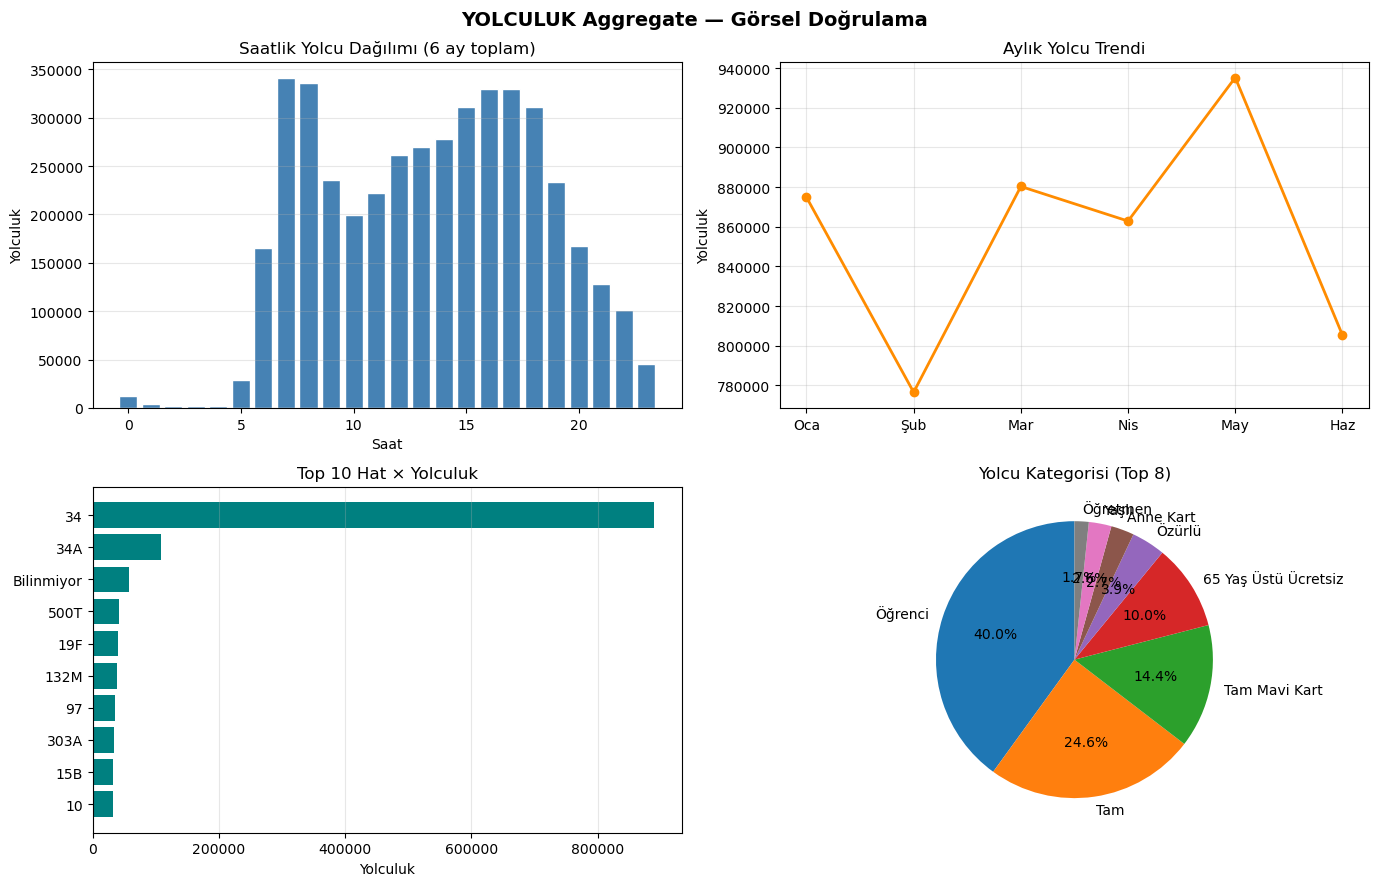

Görsel kaydedildi: yolculuk_dogrulama.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('YOLCULUK Aggregate — Görsel Doğrulama', fontsize=14, fontweight='bold')

# Saat dağılımı
ax = axes[0, 0]
saatler = list(range(24))
yolcular = [saat.get(s, 0) for s in saatler]
ax.bar(saatler, yolcular, color='steelblue', edgecolor='white')
ax.set_title('Saatlik Yolcu Dağılımı (6 ay toplam)')
ax.set_xlabel('Saat')
ax.set_ylabel('Yolculuk')
ax.grid(alpha=0.3, axis='y')

# Aylık trend
ax = axes[0, 1]
aylar = sorted(ay.keys())
yolcu_ay = [ay[m] for m in aylar]
ay_isim = ['Oca','Şub','Mar','Nis','May','Haz']
ax.plot(ay_isim[:len(aylar)], yolcu_ay, marker='o', linewidth=2, color='darkorange')
ax.set_title('Aylık Yolcu Trendi')
ax.set_ylabel('Yolculuk')
ax.grid(alpha=0.3)

# Top 10 hat
ax = axes[1, 0]
top10 = [(k, v) for k, v in hat.most_common(10)]
ax.barh([k for k,_ in top10][::-1], [v for _,v in top10][::-1], color='teal')
ax.set_title('Top 10 Hat × Yolculuk')
ax.set_xlabel('Yolculuk')
ax.grid(alpha=0.3, axis='x')

# Bilet kategorisi pie
ax = axes[1, 1]
top_kat = bilet_kategori.most_common(8)
labels = [k for k,_ in top_kat]
sizes = [v for _,v in top_kat]
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Yolcu Kategorisi (Top 8)')

plt.tight_layout()
plt.savefig('yolculuk_dogrulama.png', dpi=80, bbox_inches='tight')
plt.show()
print('Görsel kaydedildi: yolculuk_dogrulama.png')

---
## ✅ Sonuç — 5 JSON Üretildi

| Dosya | iett_panel Sekmesi |
|---|---|
| `yolcu_agg.json` | 👥 Yolcu |
| `bilet_agg.json` | 🎫 Bilet |
| `filo_yolcu_agg.json` | 🚌 Filo |
| `operator_garaj_agg.json` | 🏭 Garaj |
| `aktarma_pattern.json` | 🔍 Hat Analizi |
| `hat_saat_isi.json` | 🔍 Hat Analizi (ısı haritası) |

**Hedef konum:** `Datathon/panel_data/` (iett_panel'in services.py'sı buradan yüklüyor)

**Test:**
1. iett_panel'i restart et
2. Log'da `[PANEL] yolcu_agg.json yuklendi`, `[PANEL] bilet_agg.json yuklendi` görmelisin
3. http://localhost:5000/panel/2025 — Yolcu, Bilet, Filo, Garaj sekmeleri dolacak

In [11]:
# Son özet
ozet = {
    'yolcu_agg.json': os.path.getsize(f'{OUT_DIR}/yolcu_agg.json'),
    'bilet_agg.json': os.path.getsize(f'{OUT_DIR}/bilet_agg.json'),
    'filo_yolcu_agg.json': os.path.getsize(f'{OUT_DIR}/filo_yolcu_agg.json'),
    'operator_garaj_agg.json': os.path.getsize(f'{OUT_DIR}/operator_garaj_agg.json'),
    'aktarma_pattern.json': os.path.getsize(f'{OUT_DIR}/aktarma_pattern.json'),
    'hat_saat_isi.json': os.path.getsize(f'{OUT_DIR}/hat_saat_isi.json'),
}
print('=== ÜRETİLEN JSONlar ===')
for ad, b in ozet.items():
    print(f'  {ad:<30s} {b/1024:>8.1f} KB')
print(f'\nToplam: {sum(ozet.values())/1024:.1f} KB')
print(f'\n✓ Tüm dosyalar {os.path.abspath(OUT_DIR)}/ klasöründe')

=== ÜRETİLEN JSONlar ===
  yolcu_agg.json                     14.8 KB
  bilet_agg.json                     28.1 KB
  filo_yolcu_agg.json                 5.0 KB
  operator_garaj_agg.json             3.0 KB
  aktarma_pattern.json               21.8 KB
  hat_saat_isi.json                   7.4 KB

Toplam: 80.1 KB

✓ Tüm dosyalar c:\Users\asus\Desktop\Datathon\panel_data/ klasöründe
